# SINDy-KANs: Sparse Identification of Nonlinear Dynamics through Kolmogorov-Arnold Networks

This tutorial demonstrates **SINDy-KANs**, a method that combines the sparse identification capabilities of SINDy with the powerful function composition of Kolmogorov-Arnold Networks (KANs) for symbolic regression.

## What You Will Learn

In this notebook, you will:
1. Understand the mathematical foundations of KANs and SINDy
2. Learn how SINDy-KANs discover interpretable symbolic equations from data
3. Apply SINDy-KANs to discover the equation $f(x, y) = \cos(x^2) + y$
4. Visualize and interpret the discovered network structure

## References

[1] [Howard, A.A., et al. (2025). SINDy-KANs: Sparse identification of non-linear dynamics through Kolmogorov-Arnold networks.](https://arxiv.org/abs/2603.18548)

[2] [Liu, Z., et al. (2024). KAN: Kolmogorov-Arnold Networks.](https://arxiv.org/abs/2404.19756)

[3] [Brunton, S.L., et al. (2016). Discovering governing equations from data by sparse identification of nonlinear dynamical systems.](https://www.pnas.org/doi/10.1073/pnas.1517384113)

---

## Background: Kolmogorov-Arnold Networks (KANs)

KANs[2] are neural networks inspired by the Kolmogorov-Arnold representation theorem, providing an alternative to traditional multilayer perceptrons (MLPs). Unlike MLPs which use fixed activation functions with trainable weights, **KANs use trainable activation functions**.

A KAN approximates a multivariate function $f(\mathbf{x})$ as:

$$
\mathscr{K}(\mathbf{x}) = \sum_{i_{L-1}=1}^{n_{L-1}}\varphi_{L-1, i_{L}, i_{L-1}}
\left(\sum_{i_{L-2}=1}^{n_{L-2}} \ldots
\left(\sum_{i_{1}=1}^{n_{1}}\varphi_{1, i_2, i_1}
\left(\sum_{i_{0}=1}^{n_{0}}\varphi_{0, i_1, i_0}(x_{i_0})
\right)
\right) \ldots
\right)
$$

where $\varphi_{\ell, j, i}$ are **trainable univariate activation functions** represented by splines.

### Key Insight
The power of KANs lies in their ability to represent **compositions of functions** through depth. A two-layer KAN can represent $\cos(x^2)$ by:
- First layer: learns $x^2$
- Second layer: learns $\cos(\cdot)$

This compositional structure enables discovering complex nested relationships in data.

---

## SINDy-KANs: Combining SINDy with KANs

**Sparse Identification of Nonlinear Dynamics (SINDy)** [3] discovers interpretable equations by representing functions as sparse linear combinations of basis functions:

$$\phi(x) = \sum_{i} \xi_i \theta_i(x)$$

where $\theta_i(x)$ are basis functions (e.g., $1, x, x^2, \sin(x), \cos(x)$) and $\xi_i$ are learnable coefficients. The key insight is that **sparsity leads to interpretability**—instead of learning $0.001 + 0.999x^2 + 0.002\sin(x)$, we want simply $x^2$.

**SINDy-KANs** combine this sparse identification with the compositional power of KANs. Each activation function $\phi_{\ell, j, i}$ is represented as:

$$\phi_{\ell, j, i}(x) = \mathbf{\Theta}(x) \cdot \boldsymbol{\xi}_{\ell, j, i}$$

### The Loss Function

The general SINDy-KAN loss function is:

$$\mathscr{L} = \lambda_{KAN} \mathscr{L}_{KAN} + \lambda_S \mathscr{L}_S + \lambda_\Lambda \mathscr{L}_\Lambda + \lambda_1 \lVert\Lambda\rVert_1 + \lambda_2 \lVert\Lambda - \Xi_S\rVert_2^2$$

where:

- $\mathscr{L}_{KAN}$: KAN reconstruction loss. For **direct** SINDy-KANs, $\lambda_{KAN}=0$.
- $\mathscr{L}_S$: SINDy reconstruction — how well the symbolic form fits the data.
- $\mathscr{L}_\Lambda$: Sparse reconstruction — how well the thresholded form fits.
- $\lVert\Lambda\rVert_1$: L1 sparsity penalty on coefficients.
- $\lVert\Lambda - \Xi_S\rVert_2^2$: Sparse-dense alignment — keeps sparse $\Lambda$ close to learned $\Xi_S$.

### Direct vs. Indirect Methods

- **Direct**: Coefficients $\Xi_S$ are learned directly as trainable parameters (faster)
- **Indirect**: A KAN is trained first, then coefficients are found via least squares (more flexible)

In this tutorial, we use the **direct** method ($\lambda_{KAN} = 0$).

---

## This Tutorial: Discovering $f(x, y) = \cos(x^2) + y$

We will discover the equation:

$$f(x, y) = \cos(x^2) + y, \quad (x, y) \in [-2.5, 2.5]^2$$

This example is from **Section 3.1.2 of the SINDy-KAN paper** [1].

### Why This Example?

This equation contains a **composition of functions** ($\cos$ composed with $x^2$), which:
- Would be difficult to include in a standard SINDy library
- Demonstrates the power of multi-layer KANs for nested functions


---

### Install Neuromancer

If running on Google Colab, uncomment and run the cell below. For local installations, you can skip this step.

In [ ]:
# # Uncomment below for Colab installation
# import os
#
# if not os.path.isdir('neuromancer'):
#     !git clone -b sindy-kans https://github.com/pnnl/neuromancer.git
# %cd neuromancer
# !pip install -e .[docs,tests,examples]

### Import Dependencies

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import time

from neuromancer.modules.sindy_kan import SINDyKANBlock

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


---

## Generate Training Data

We generate training data by sampling random points from the domain $[-2.5, 2.5]^2$ and evaluating our target function.

$$f(x, y) = \cos(x^2) + y$$

In [3]:
def target_function(x, y):
    """The ground truth function we want to discover."""
    return torch.cos(x**2) + y

# Generate random training samples
n_train = 100
x_train = torch.rand(n_train, 1) * 5 - 2.5  # Uniform in [-2.5, 2.5]
y_train = torch.rand(n_train, 1) * 5 - 2.5  # Uniform in [-2.5, 2.5]

# Combine inputs and compute outputs
X_train = torch.cat([x_train, y_train], dim=1).to(device)
z_train = target_function(x_train, y_train).to(device)

print(f"Training data shapes:")
print(f"  Inputs X:  {X_train.shape} ({n_train} samples, 2 features: x and y)")
print(f"  Outputs z: {z_train.shape} ({n_train} samples, 1 output)")

Training data shapes:
  Inputs X:  torch.Size([100, 2]) (100 samples, 2 features: x and y)
  Outputs z: torch.Size([100, 1]) (100 samples, 1 output)


### Visualize the Target Function

Let's visualize what we're trying to learn: the function $f(x, y) = \cos(x^2) + y$

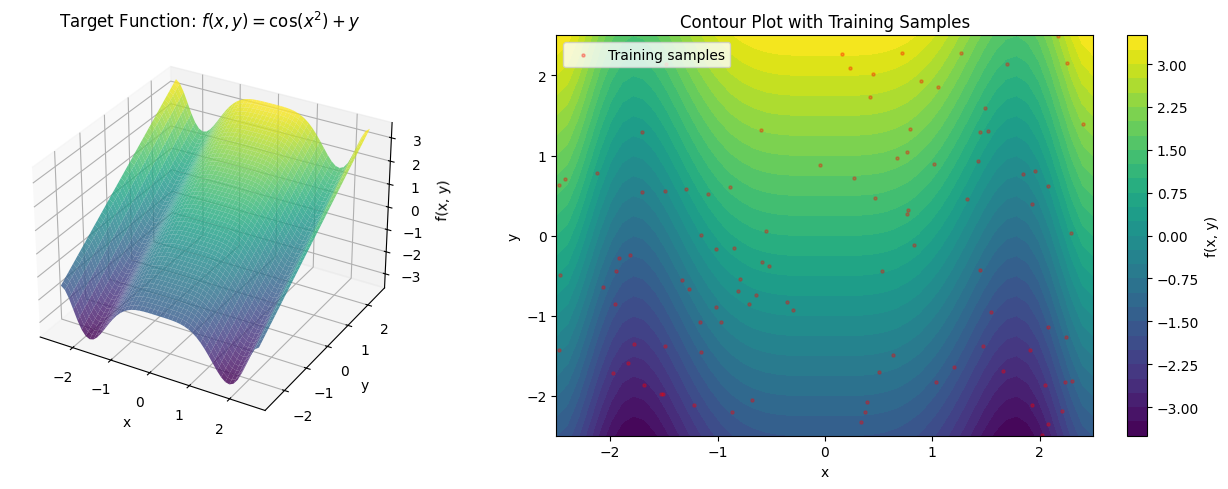

In [4]:
# Create a grid for visualization
x_grid = torch.linspace(-2.5, 2.5, 50)
y_grid = torch.linspace(-2.5, 2.5, 50)
X_mesh, Y_mesh = torch.meshgrid(x_grid, y_grid, indexing='ij')
Z_mesh = target_function(X_mesh, Y_mesh)

# Create figure with two subplots
fig = plt.figure(figsize=(14, 5))

# 3D surface plot
ax1 = fig.add_subplot(121, projection='3d')
surf = ax1.plot_surface(X_mesh.numpy(), Y_mesh.numpy(), Z_mesh.numpy(), 
                        cmap='viridis', alpha=0.8, antialiased=True)
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('f(x, y)')
ax1.set_title(r'Target Function: $f(x, y) = \cos(x^2) + y$')

# Contour plot
ax2 = fig.add_subplot(122)
contour = ax2.contourf(X_mesh.numpy(), Y_mesh.numpy(), Z_mesh.numpy(), 
                       levels=30, cmap='viridis')
ax2.scatter(X_train[:, 0].cpu(), X_train[:, 1].cpu(), c='red', s=5, alpha=0.3, label='Training samples')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('Contour Plot with Training Samples')
ax2.legend()
plt.colorbar(contour, ax=ax2, label='f(x, y)')

plt.tight_layout()
plt.show()

---

## Create the SINDy-KAN Model

We create a SINDy-KAN with the following configuration:

### Architecture: `[2, 2, 1]`
- **2 inputs**: $x$ and $y$
- **2 hidden nodes**: Intermediate representations
- **1 output**: $f(x, y)$

### Basis Library
We use polynomials up to degree 2 plus trigonometric functions:
$$\Theta(x) = [1, x, x^2, \sin(x), \cos(x)]$$

This library is chosen because:
- $x^2$ is needed to learn the first layer
- $\cos(x)$ is needed to learn the second layer

### Hyperparameters
| Parameter | Value | Description |
|-----------|-------|-------------|
| `lambda_kan` | 0.0 | Direct method: no KAN loss |
| `lambda_s` | 1.0 | Weight for SINDy reconstruction |
| `lambda_lam` | 1.0 | Weight for sparse reconstruction |
| `lambda_l1` | 0.0001 | L1 sparsity penalty (small) |
| `lambda_diff` | 0.001 | Sparse-dense alignment weight |

In [5]:
# Create the SINDy-KAN model
sindy_kan = SINDyKANBlock(
    insize=2,              # Number of inputs (x, y)
    outsize=1,             # Number of outputs (f(x,y))
    hsizes=[2],            # Hidden layer sizes
    poly_order=2,          # Polynomial terms: 1, x, x^2
    include_trig=True,     # Add sin(x), cos(x) to library
    lambda_kan=0.0,        # λ_KAN = 0 for direct method
    lambda_s=1.0,          # λ_S: SINDy reconstruction weight
    lambda_lam=1.0,        # λ_Λ: Sparse reconstruction weight  
    lambda_l1=0.001,      # λ_1: L1 sparsity penalty
    lambda_diff=0.001,     # λ_2: Sparse-dense alignment
).to(device)

# Print model info
print(f"SINDy-KAN Architecture: [2, 2, 1]")
print(f"Basis functions: {sindy_kan.basis.function_names}")
print(f"Total parameters: {sum(p.numel() for p in sindy_kan.parameters())}")

SINDy-KAN Architecture: [2, 2, 1]
Basis functions: ['1', 'x', 'x^2', 'cos(x)', 'sin(x)']
Total parameters: 60


---

## Training the SINDy-KAN

We train the model using the Adam optimizer with a learning rate schedule. The training process:

1. **Forward pass**: Compute predictions and loss
2. **Backward pass**: Compute gradients
3. **Update**: Adjust coefficients to minimize loss

During training, the L1 penalty encourages sparsity, pushing small coefficients toward zero.

In [6]:
# Training configuration
num_epochs = 20000
learning_rate = 1e-3

# Optimizer and scheduler
optimizer = torch.optim.Adam(sindy_kan.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30000, gamma=0.5)

# History tracking
history = {'loss': []}

print("Training SINDy-KAN...")
print("=" * 40)
print(f"{'Epoch':>8} | {'Total Loss':>12}")
print("-" * 40)

start_time = time.time()

for epoch in range(num_epochs):
    # Forward pass and loss computation
    loss_dict = sindy_kan.compute_loss(X_train, z_train)
    loss = loss_dict['loss']
    
    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    scheduler.step()
    
    # Record history
    history['loss'].append(float(loss))
    
    # Print progress every 10000 epochs
    if (epoch + 1) % 5000 == 0:
        print(f"{epoch+1:>8} | {float(loss):>12.6f}")

print("=" * 40)
print(f"Training completed in {time.time() - start_time:.1f} seconds")

Training SINDy-KAN...
   Epoch |   Total Loss
----------------------------------------


/var/folders/62/7d_qbnz11c38bp1g8g9b61100000gn/T/ipykernel_9533/3072717368.py:31: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:837.)
  history['loss'].append(float(loss))


    5000 |     0.011137
   10000 |     0.006572
   15000 |     0.004642
   20000 |     0.004579
Training completed in 8.2 seconds


### Plot Training Progress

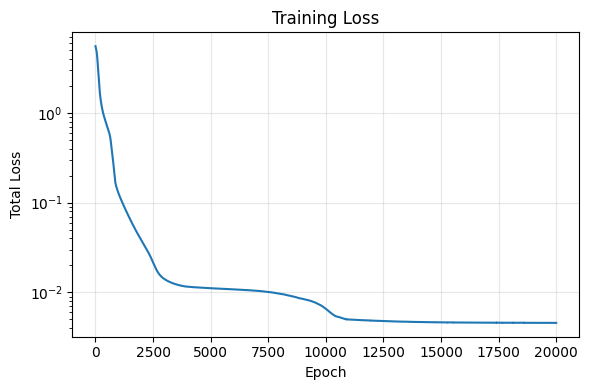

In [7]:
plt.figure(figsize=(6, 4))
plt.semilogy(history['loss'])
plt.xlabel('Epoch')
plt.ylabel('Total Loss')
plt.title('Training Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## Discover the Symbolic Equation

After training, we print the discovered equations from the learned sparse coefficients.

In [8]:
# Print discovered equations
print("Discovered Symbolic Equations")
print("=" * 50)
sindy_kan.print_equations(input_names=['x', 'y'])
print("=" * 50)
print(f"\nExpected: f(x, y) = cos(x²) + y")

Discovered Symbolic Equations
LEARNED SINDY-KAN EQUATIONS

Layer 0 → 1:
  (2 inputs → 2 outputs)
  Node 0: -0.9996*x^2
  Node 1: 1.0367*y

Layer 1 → 2:
  (2 inputs → 1 outputs)
  Node 0: 0.9987*cos(-0.9996*x^2) + 0.9641*1.0367*y

FINAL OUTPUT EQUATIONS:
  f_0 = 0.9987*cos(-0.9996*x^2) + 0.9641*1.0367*y

Expected: f(x, y) = cos(x²) + y


### Visualize the SINDy-KAN Network

The `plot_network()` method visualizes:
- The network architecture as a graph
- The learned activation functions on each edge
- The symbolic equation associated with each edge

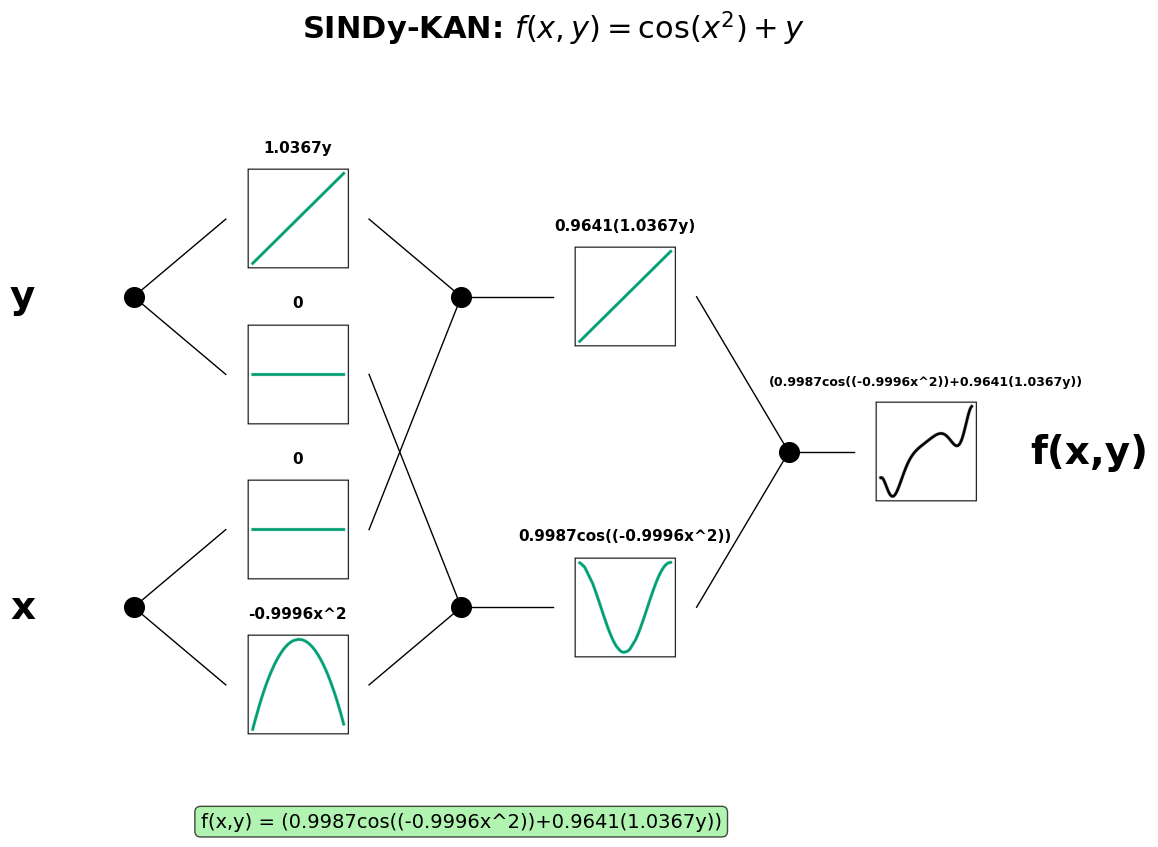

In [9]:
# Visualize the trained network
fig, ax = sindy_kan.plot_network(
    input_names=['x', 'y'],
    output_names=['f(x,y)'],
    title=r'SINDy-KAN: $f(x,y) = \cos(x^2) + y$',
    x=X_train
)
plt.show()

---

## Evaluate Model Accuracy

We evaluate the trained model by comparing predictions against ground truth on a grid.

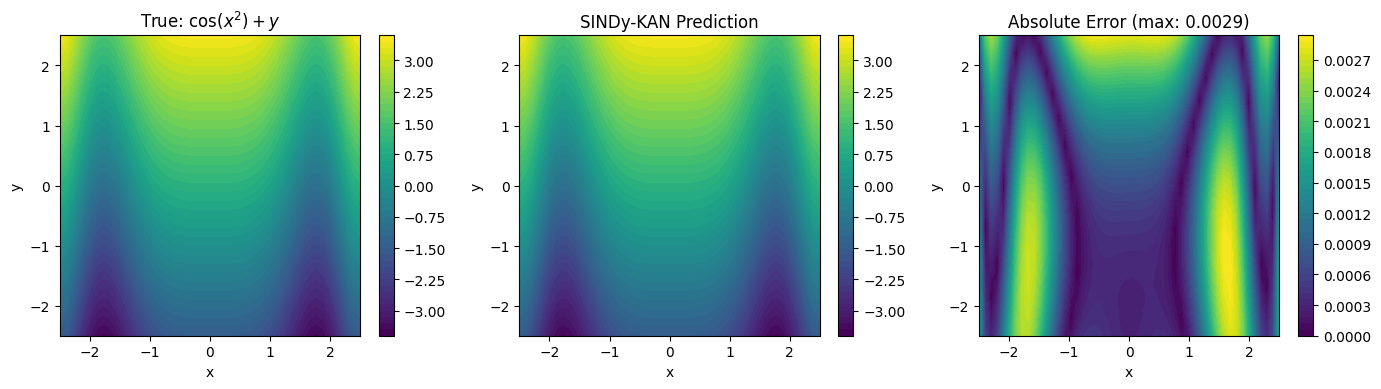

In [10]:
# Visualize predictions
n_grid = 50
x_grid = torch.linspace(-2.5, 2.5, n_grid)
y_grid = torch.linspace(-2.5, 2.5, n_grid)
X_mesh, Y_mesh = torch.meshgrid(x_grid, y_grid, indexing='ij')

XY_grid = torch.cat([X_mesh.flatten().unsqueeze(1), 
                      Y_mesh.flatten().unsqueeze(1)], dim=1).to(device)

with torch.no_grad():
    Z_pred = sindy_kan(XY_grid, use_sparse=True).reshape(n_grid, n_grid).cpu()

Z_true = target_function(X_mesh, Y_mesh)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

im0 = axes[0].contourf(X_mesh, Y_mesh, Z_true, levels=50, cmap='viridis')
axes[0].set_title('True: $\\cos(x^2) + y$')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].contourf(X_mesh, Y_mesh, Z_pred, levels=50, cmap='viridis')
axes[1].set_title('SINDy-KAN Prediction')
plt.colorbar(im1, ax=axes[1])

error = torch.abs(Z_pred - Z_true)
im2 = axes[2].contourf(X_mesh, Y_mesh, error, levels=50, cmap='viridis')
axes[2].set_title(f'Absolute Error (max: {error.max():.4f})')
plt.colorbar(im2, ax=axes[2])

for ax in axes:
    ax.set_xlabel('x'); ax.set_ylabel('y')

plt.tight_layout()
plt.show()

---

## Summary

In this tutorial, we demonstrated how **SINDy-KANs** can discover interpretable symbolic equations from data:

### What We Accomplished

1. **Generated data** from the target function $f(x, y) = \cos(x^2) + y$
2. **Trained a SINDy-KAN** with a `[2, 2, 1]` architecture and polynomial + trigonometric basis
3. **Discovered the symbolic equation** using the sparse coefficients
4. **Visualized** the network structure and learned activation functions
5. **Evaluated accuracy** achieving low error on the test grid

### Key Takeaways

- **SINDy-KANs combine the best of both worlds**: The compositional power of KANs with SINDy's sparse identification
- **Function compositions** like $\cos(x^2)$ are naturally handled by multi-layer architectures
- **Sparsity constraints** (L1 penalty, sparse-dense alignment) are crucial for discovering clean equations

### Further Exploration

Try modifying:
- The target function (e.g., $f(x, y) = \sin(x + y^2)$)
- The basis library (add/remove functions)
- The network architecture (more/fewer hidden nodes)
- The loss hyperparameters (`lambda_l1`, `lambda_diff`)

---

## References

[1] Howard, A.A., Zolman, N., Jacob, B., Brunton, S.L., & Stinis, P. (2025). *SINDy-KANs: Sparse identification of non-linear dynamics through Kolmogorov-Arnold networks.* arXiv preprint.

[2] Liu, Z., Wang, Y., Vaidya, S., Ruehle, F., Halverson, J., Soljacic, M., Hou, T.Y., & Tegmark, M. (2024). *KAN: Kolmogorov-Arnold Networks.* arXiv:2404.19756.

[3] Brunton, S.L., Proctor, J.L., & Kutz, J.N. (2016). *Discovering governing equations from data by sparse identification of nonlinear dynamical systems.* PNAS, 113(15), 3932-3937.